# *ASSIGNMENT-0: Measures on a large graph*

In [1]:
import pandas as pd
from pathlib import Path
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import random
import numpy as np
from collections import Counter
import powerlaw
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
BASE_DIR = Path().resolve().parent
DATASET_PATH = BASE_DIR / "data" / "anime_info.csv"
df = pd.read_csv(DATASET_PATH)

In [3]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 29816
Columns: 39


In [4]:
print("MISSING VALUES")
missing = df.isnull().sum().sort_values(ascending=False)
print(missing[missing > 0])

MISSING VALUES
opening_themes    29816
ending_themes     29816
trailer_url       29816
background        26554
broadcast_day     25254
broadcast_time    25254
licensors         24632
season            23294
year              23294
demographics      18767
aired_to          18237
title_english     16579
producers         15604
title_synonyms    15193
themes            11990
studios           11742
score             10030
scored_by         10030
rank               7405
genres             6297
synopsis           4970
aired_from          904
episodes            833
content_rating      612
title_japanese      121
type                 69
dtype: int64


In [5]:
print("SAMPLE ANIME")
sample = df[
    [
        "title",
        "genres",
        "themes",
        "demographics",
        "score",
        "members",
    ]
].head(10)
display(sample)

SAMPLE ANIME


,title,genres,themes,demographics,score,members
0,Cowboy Bebop,Action|Award Winning|Sci-Fi,Adult Cast|Space,NaN,8.75,2060957
1,Cowboy Bebop: Tengoku no Tobira,Action|Sci-Fi,Adult Cast|Space,NaN,8.38,412490
2,Trigun,Action|Adventure|Sci-Fi,Adult Cast,Shounen,8.22,835922
3,Witch Hunter Robin,Action|Drama|Mystery|Supernatural,Detective,NaN,7.24,129660
4,Bouken Ou Beet,Action|Adventure|Fantasy,NaN,Shounen,6.96,16635
5,Eyeshield 21,Sports,Team Sports,Shounen,7.91,196013
6,Hachimitsu to Clover,Comedy|Drama|Romance,Adult Cast|Love Polygon|Visual Arts,Josei,7.98,285691
7,Hungry Heart: Wild Striker,Sports,Team Sports,Shounen,7.56,26748
8,Initial D Fourth Stage,Action|Drama,Racing,Seinen,8.18,215675
9,Monster,Drama|Mystery|Suspense,Adult Cast|Psychological,Seinen,8.89,1333646


In [6]:
print("TYPE DISTRIBUTION")
display(df["type"].value_counts())

TYPE DISTRIBUTION


type
TV            8682
Movie         4966
ONA           4294
Music         4248
OVA           4205
Special       1750
TV Special     792
CM             497
PV             313
Name: count, dtype: int64

In [7]:
print("DEMOGRAPHICS")
display(df["demographics"].value_counts(dropna=False))

DEMOGRAPHICS


demographics
NaN               18767
Kids               6895
Shounen            2207
Seinen             1194
Shoujo              541
Josei               160
Kids|Shounen         50
Kids|Shoujo           1
Seinen|Shounen        1
Name: count, dtype: int64

In [8]:
print("TOP 20 BY MEMBERS")
top_members = (
    df[["title", "members"]]
    .sort_values("members", ascending=False)
    .head(20)
)
display(top_members)

TOP 20 BY MEMBERS


,title,members
7379,Shingeki no Kyojin,4370845
1388,Death Note,4308593
3941,Fullmetal Alchemist: Brotherhood,3691258
10312,One Punch Man,3526041
14393,Kimetsu no Yaiba,3457513
11029,Boku no Hero Academia,3313023
6553,Sword Art Online,3305192
6415,Hunter x Hunter (2011),3196311
10,Naruto,3123350
8541,Tokyo Ghoul,3061870


In [9]:
print("TOP 20 BY SCORE")
top_score = (
    df[df["score"].notna()][["title", "score"]]
    .sort_values("score", ascending=False)
    .head(20)
)
display(top_score)

TOP 20 BY SCORE


,title,score
22788,Sousou no Frieren,9.26
28106,Steel Ball Run: JoJo no Kimyou na Bouken,9.13
3941,Fullmetal Alchemist: Brotherhood,9.11
5633,Steins;Gate,9.07
25646,Chainsaw Man Movie: Reze-hen,9.07
15346,Gintama: The Final,9.05
14711,Shingeki no Kyojin Season 3 Part 2,9.05
9788,Gintama°,9.05
6415,Hunter x Hunter (2011),9.03
7192,Gintama': Enchousen,9.02


In [10]:
print("MOST COMMON GENRES")
genre_counter = {}
for genres in df["genres"].dropna():
    for genre in str(genres).split("|"):
        genre = genre.strip()
        if genre:
            genre_counter[genre] = genre_counter.get(genre, 0) + 1
genre_df = (
    pd.DataFrame(genre_counter.items(), columns=["genre", "count"])
    .sort_values("count", ascending=False)
)
display(genre_df.head(20))

MOST COMMON GENRES


,genre,count
9,Comedy,7910
7,Fantasy,6181
0,Action,4965
3,Adventure,4570
2,Sci-Fi,3533
4,Drama,3152
10,Romance,2292
18,Hentai,1612
6,Supernatural,1568
19,Slice of Life,1266


## FILTER

In [11]:
filtered = df[
    (df["members"] >= 50000)
    & (df["genres"].notna())
]
filtered = filtered.drop_duplicates(subset="mal_id")
filtered.to_csv(BASE_DIR / "data" / "anime_filtered.csv", index=False)
print(f"Filtered rows: {filtered.shape[0]}")
print(f"Non-filtered rows: {df.shape[0]}")

Filtered rows: 3579
Non-filtered rows: 29816


In [12]:
def build_graph(filtered):
    G = nx.Graph()
    for _, row in filtered.iterrows():
        G.add_node(row["mal_id"], title=row["title"])
    for (_, a), (_, b) in combinations(filtered.iterrows(), 2):
        genres_a = set(str(a["genres"]).split("|"))
        genres_b = set(str(b["genres"]).split("|"))
        if len(genres_a & genres_b) >= 2:
            G.add_edge(a["mal_id"], b["mal_id"])
    return G

In [13]:
G = build_graph(filtered=filtered)

In [14]:
print(G.number_of_nodes())
print(G.number_of_edges())

3579
780393


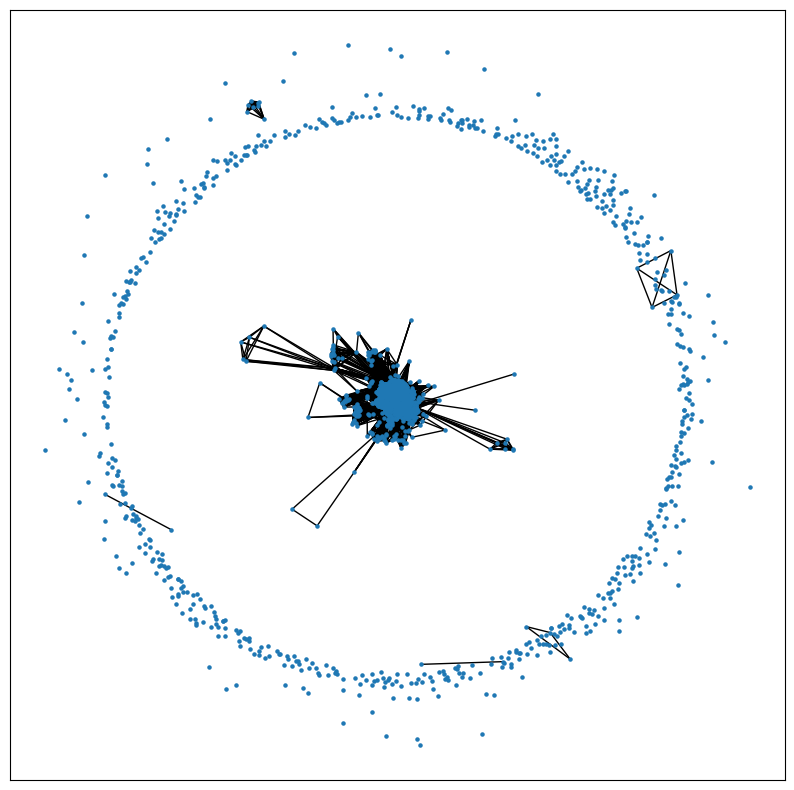

In [15]:
plt.figure(figsize=(10,10))
nx.draw_networkx(G, with_labels=False, node_size=5)
plt.show()

## ANALYSIS

## Random network or power-law network?

In [16]:
def analyze_degree_distribution(G):
    degrees = [d for _, d in G.degree()] # lista dei gradi

    # Degree distribution
    degree_counts = Counter(degrees) # quanti nodi hanno ciascun grado
    x = sorted(degree_counts.keys()) # ordino i gradi
    y = [degree_counts[k] for k in x] # nodi con quel grado

    plt.figure(figsize=(8,5))
    plt.hist(degrees, bins=50, edgecolor="black")
    plt.title("Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.show()

    # Log-log plot: grafico della degree distribution in scala logaritmica su entrambi gli assi
    plt.figure(figsize=(8,5))
    plt.scatter(x, y)
    plt.xscale("log")
    plt.yscale("log")
    plt.xlabel("Degree")
    plt.ylabel("Frequency")
    plt.title("Degree Distribution (Log-Log)")
    plt.show()

    # Power law fit
    fit = powerlaw.Fit(
        degrees,
        discrete=True,
        verbose=False
    )

    print("===== POWER LAW FIT =====")
    print(f"alpha = {fit.alpha:.3f}") # esponente della power law
    print(f"xmin  = {fit.xmin}") # valore di degree da cui inizia la parte della distribuzione che viene considerata compatibile con la power law

    # Confronto con altre distribuzioni
    comparisons = [
        ("power_law", "exponential"),
        ("power_law", "lognormal"),
        ("power_law", "truncated_power_law"),
        ("power_law", "stretched_exponential")
    ]

    print("\n===== DISTRIBUTION COMPARISON =====")
    best = None
    best_score = 0
    for power_law, other_distribution in comparisons:
        try:
            R, p = fit.distribution_compare(power_law, other_distribution)
            print(f"{power_law} vs {other_distribution}")
            print(f"R = {R:.3f}")
            print(f"p = {p:.3f}")
            # Se R > 0 la power law è favorita
            # Se R < 0 l'altra distribuzione è favorita
            # Il p-value indica se la differenza è statisticamente significativa
            if R > 0:
                if p < 0.05:
                    print(f"Better: {power_law} (statistically significant)\n")
                    if best is None:
                        best = power_law
                else:
                    print(f"Better: {power_law}, but the difference is not significant\n")
            elif R < 0:
                if p < 0.05:
                    print(f"Better: {other_distribution} (statistically significant)\n")
                    if abs(R) > best_score:
                        best_score = abs(R)
                        best = other_distribution
                else:
                    print(f"Better: {other_distribution}, but the difference is not significant\n")
            else:
                print("No significant difference between the two distributions\n")
        except Exception as e:
            print(e)
    print("===== INTERPRETATION =====")
    if best == "power_law":
        print("The network shows scale-free characteristics.")
    else:
        print("The network does not follow a pure power law.")
        print(f"Best alternative distribution: {best}")

In [17]:
def analyze_random_graph(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()

    # Probability p of an Erdős-Rényi graph
    p = (2 * m) / (n * (n - 1))

    print("\n===== RANDOM GRAPH COMPARISON =====")
    print(f"Original graph: N = {n}, E = {m}")
    print(f"Erdős-Rényi p = {p:.6f}")

    # Generate random graph with same number of nodes
    G_random = nx.erdos_renyi_graph(n, p, seed=42)

    # Degree
    avg_degree_original = sum(dict(G.degree()).values()) / n
    avg_degree_random = sum(dict(G_random.degree()).values()) / n

    print(f"\nAverage degree:")
    print(f"Original: {avg_degree_original:.2f}")
    print(f"Random:   {avg_degree_random:.2f}")

    # Clustering
    clustering_original = nx.average_clustering(G)
    clustering_random = nx.average_clustering(G_random)

    print(f"\nAverage clustering:")
    print(f"Original: {clustering_original:.4f}")
    print(f"Random:   {clustering_random:.4f}")

    # Average shortest path
    if nx.is_connected(G):
        path_original = nx.average_shortest_path_length(G)
    else:
        largest_cc = max(nx.connected_components(G), key=len)
        G_lcc = G.subgraph(largest_cc)
        path_original = nx.average_shortest_path_length(G_lcc)

    if nx.is_connected(G_random):
        path_random = nx.average_shortest_path_length(G_random)
    else:
        largest_cc_random = max(nx.connected_components(G_random), key=len)
        G_random_lcc = G_random.subgraph(largest_cc_random)
        path_random = nx.average_shortest_path_length(G_random_lcc)

    print(f"\nAverage shortest path length:")
    print(f"Original: {path_original:.4f}")
    print(f"Random:   {path_random:.4f}")

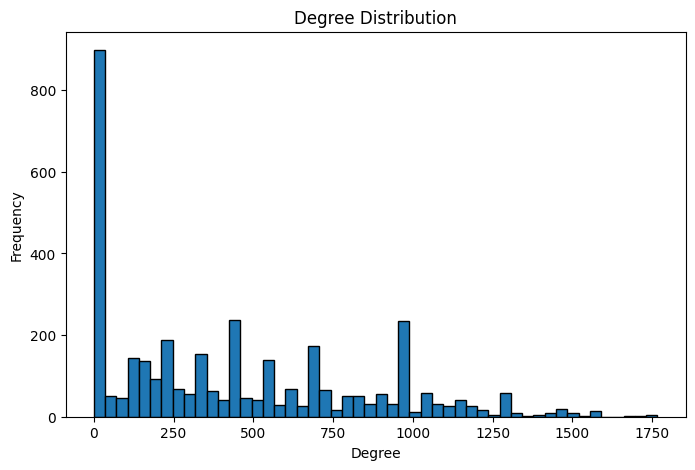

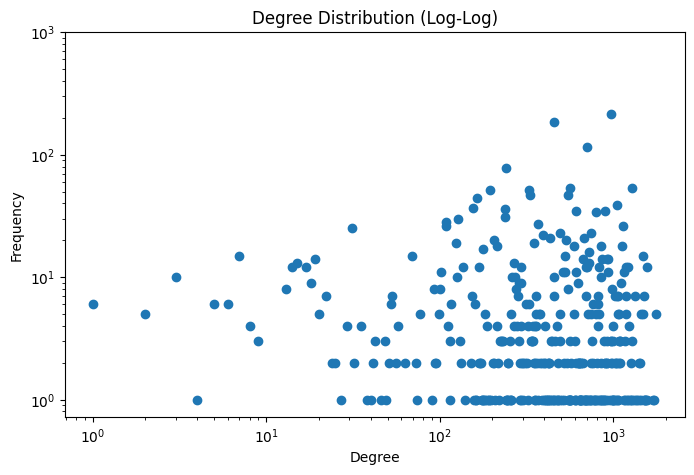

===== POWER LAW FIT =====
alpha = 2.897
xmin  = 454.0

===== DISTRIBUTION COMPARISON =====
power_law vs exponential
R = -187.794
p = 0.000
Better: exponential (statistically significant)

power_law vs lognormal
R = -196.488
p = 0.000
Better: lognormal (statistically significant)

power_law vs truncated_power_law
R = -186.996
p = 0.000
Better: truncated_power_law (statistically significant)

power_law vs stretched_exponential
R = -246.137
p = 0.000
Better: stretched_exponential (statistically significant)

===== INTERPRETATION =====
The network does not follow a pure power law.
Best alternative distribution: stretched_exponential


In [18]:
analyze_degree_distribution(G)

In [19]:
analyze_random_graph(G)


===== RANDOM GRAPH COMPARISON =====
Original graph: N = 3579, E = 780393
Erdős-Rényi p = 0.121882

Average degree:
Original: 436.10
Random:   436.67

Average clustering:
Original: 0.6296
Random:   0.1221

Average shortest path length:
Original: 1.9320
Random:   1.8780


### Most important nodes (centrality)

In [20]:
def analyze_centrality(G, top_n=10):
    degree = nx.degree_centrality(G)
    top_nodes = sorted(degree.items(), key=lambda x: x[1], reverse=True)[:top_n]
    centrality = pd.DataFrame(
        [
            (G.nodes[node].get("title", node), value)
            for node, value in top_nodes
        ],
        columns=["Node", "Degree Centrality"]
    )
    print("===== TOP CENTRAL NODES =====")
    display(centrality)


In [21]:
analyze_centrality(G)

===== TOP CENTRAL NODES =====


,Node,Degree Centrality
0,Zero no Tsukaima,0.493851
1,Zero no Tsukaima: Futatsuki no Kishi,0.493851
2,Zero no Tsukaima: Princesses no Rondo,0.493851
3,Zero no Tsukaima: Princesses no Rondo Picture ...,0.493851
4,Zero no Tsukaima F,0.493851
5,Kurenai no Buta,0.477921
6,Groove Adventure Rave,0.474008
7,One Piece Film: Red,0.438513
8,Mahou Sensei Negima!,0.436277
9,Ichiban Ushiro no Daimaou,0.436277


### Are paths short?

In [22]:
def analyze_paths(G):
    largest = max(nx.connected_components(G), key=len)
    H = G.subgraph(largest).copy()
    diameter = nx.diameter(H)
    sample_size = min(50, H.number_of_nodes())
    sample_nodes = random.sample(list(H.nodes()), sample_size)
    path_lengths = []
    for node in sample_nodes:
        lengths = nx.single_source_shortest_path_length(H, node)
        path_lengths.extend(lengths.values())
    average_path = (sum(path_lengths)/len(path_lengths))
    print("===== PATH ANALYSIS =====")
    print(f"Diameter: {diameter}")
    print(f"Average shortest path: {average_path:.3f}")

In [23]:
analyze_paths(G)

===== PATH ANALYSIS =====
Diameter: 5
Average shortest path: 1.935


### Is the network dense?

In [24]:
def analyze_density(G):
    density = nx.density(G)
    average_degree = (sum(dict(G.degree()).values()) / G.number_of_nodes())
    print("===== DENSITY =====")
    print(f"Density: {density:.6f}")
    print(f"Average degree: {average_degree:.2f}")
    if density > 0.1:
        print("The network is dense.")
    else:
        print("The network is sparse.")

In [25]:
analyze_density(G)

===== DENSITY =====
Density: 0.121882
Average degree: 436.10
The network is dense.


### Is the network assortative?

In [26]:
def analyze_assortativity(G):
    assortativity = nx.degree_assortativity_coefficient(G)
    print("===== ASSORTATIVITY =====")
    print(f"Assortativity: {assortativity:.4f}")
    if assortativity > 0:
        print("The network is assortative.")
    elif assortativity < 0:
        print("The network is disassortative.")
    else:
        print("No assortative mixing.")

In [27]:
analyze_assortativity(G)

===== ASSORTATIVITY =====
Assortativity: 0.1745
The network is assortative.


In [28]:
clustering = nx.average_clustering(G)
print(f"Average clustering coefficient: {clustering:.4f}")

Average clustering coefficient: 0.6296
